Loading MNIST data...
Data loaded: (60000, 784), (60000,)
Starting training...
Epoch 1/150 - Test Accuracy: 93.80%
Epoch 2/150 - Test Accuracy: 95.13%
Epoch 3/150 - Test Accuracy: 95.74%
Epoch 4/150 - Test Accuracy: 96.21%
Epoch 5/150 - Test Accuracy: 96.42%
Epoch 6/150 - Test Accuracy: 96.63%
Epoch 7/150 - Test Accuracy: 96.73%
Epoch 8/150 - Test Accuracy: 96.95%
Epoch 9/150 - Test Accuracy: 97.05%
Epoch 10/150 - Test Accuracy: 97.20%
Epoch 11/150 - Test Accuracy: 97.22%
Epoch 12/150 - Test Accuracy: 97.34%
Epoch 13/150 - Test Accuracy: 97.37%
Epoch 14/150 - Test Accuracy: 97.40%
Epoch 15/150 - Test Accuracy: 97.42%
Epoch 16/150 - Test Accuracy: 97.48%
Epoch 17/150 - Test Accuracy: 97.62%
Epoch 18/150 - Test Accuracy: 97.63%
Epoch 19/150 - Test Accuracy: 97.67%
Epoch 20/150 - Test Accuracy: 97.74%
Epoch 21/150 - Test Accuracy: 97.76%
Epoch 22/150 - Test Accuracy: 97.71%
Epoch 23/150 - Test Accuracy: 97.66%
Epoch 24/150 - Test Accuracy: 97.81%
Epoch 25/150 - Test Accuracy: 97.88%
Epoch

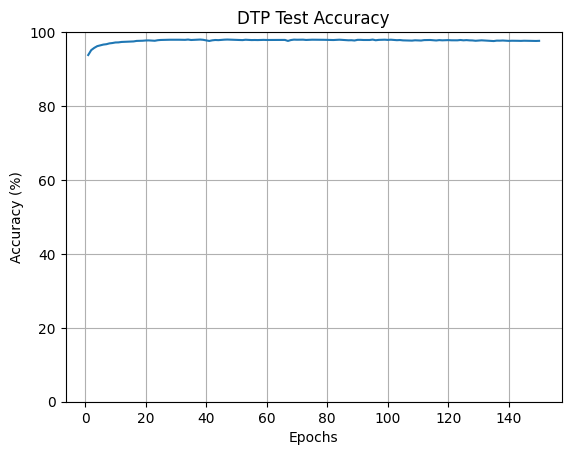

In [7]:
# Target Propagation on MNIST in JAX
# ------------------------------------------------------
# Before running in Colab, install dependencies:
# ```python
# !pip install -q --upgrade jax jaxlib optax tensorflow-datasets matplotlib
# ```

import jax
import jax.numpy as jnp
from jax import random, jit, grad
import optax
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Configuration (match report: tanh activations, 1000 hidden units)
dims = [784, 1000, 10]
NUM_CLASSES = dims[-1]
batch_size = 128
eta = 0.1
lr_fwd = 1e-3
lr_inv = 1e-3
num_epochs = 150

# 1. Data Loading and Preprocessing
print("Loading MNIST data...")
ds_train = tfds.load('mnist', split='train', batch_size=-1, as_supervised=True)
ds_test  = tfds.load('mnist', split='test',  batch_size=-1, as_supervised=True)
train_ds = tfds.as_numpy(ds_train)
test_ds  = tfds.as_numpy(ds_test)

x_train, y_train = train_ds
x_test,  y_test  = test_ds

x_train = (jnp.float32(x_train) / 255.0).reshape((-1, dims[0]))
y_train = jnp.array(y_train)
x_test  = (jnp.float32(x_test)  / 255.0).reshape((-1, dims[0]))
y_test  = jnp.array(y_test)
print(f"Data loaded: {x_train.shape}, {y_train.shape}")

# 2. Initialize forward & inverse parameters
def init_params(rng, dims):
    fwd = []
    inv  = []
    for in_dim, out_dim in zip(dims[:-1], dims[1:]):
        rng, k1, k2 = random.split(rng, 3)
        fw = random.normal(k1, (in_dim, out_dim)) * jnp.sqrt(2.0 / in_dim)
        fb = jnp.zeros((out_dim,))
        gw = random.normal(k2, (out_dim, in_dim)) * jnp.sqrt(2.0 / out_dim)
        gb = jnp.zeros((in_dim,))
        fwd.append({'w': fw, 'b': fb})
        inv.append({'w': gw, 'b': gb})
    return fwd, inv

# 3. Forward pass with tanh
def forward(fwd_params, x):
    acts = []
    h = x
    for layer in fwd_params:
        h = jnp.tanh(h @ layer['w'] + layer['b'])
        acts.append(h)
    return acts

# 4. Difference Target Propagation targets
def compute_targets(fwd_params, inv_params, acts, labels, eta):
    L = len(acts)
    targets = [None]*L
    hL = acts[-1]
    oh = jax.nn.one_hot(labels, NUM_CLASSES)
    # last-layer gradient correction
    targets[-1] = hL - eta*(hL - oh)
    # backward difference propagation
    for i in range(L-1, 0, -1):
        h_curr = acts[i-1]
        h_next = acts[i]
        t_next = targets[i]
        inv = inv_params[i]
        g_h = jnp.tanh(h_next @ inv['w'] + inv['b'])
        g_t = jnp.tanh(t_next @ inv['w']   + inv['b'])
        targets[i-1] = h_curr - g_h + g_t
    return targets

# 5. Loss functions
# Forward-layer local loss: MSE to target
def fwd_loss(fwd_params, inv_params, x, y):
    acts = forward(fwd_params, x)
    targs = compute_targets(fwd_params, inv_params, acts, y, eta)
    loss = 0.0
    inp = x
    for h, t, layer in zip(acts, targs, fwd_params):
        loss += jnp.mean((layer['w'].T @ inp.T).T * 0 + jnp.mean((h - t)**2))
        inp = h
    return loss
# Inverse nets loss: reconstruct corrupted activations
def inv_loss(inv_params, fwd_params, x):
    acts = forward(fwd_params, x)
    h_prev, h_last = acts[0], acts[-1]
    rec_prev = jnp.tanh(h_last @ inv_params[-1]['w'] + inv_params[-1]['b'])
    rec_x    = jnp.tanh(h_prev @ inv_params[0]['w']    + inv_params[0]['b'])
    return jnp.mean((rec_prev - h_prev)**2) + jnp.mean((rec_x - x)**2)

# 6. Optimizers
fwd_opt = optax.adam(lr_fwd)
inv_opt = optax.adam(lr_inv)

@jit
def train_step(fwd_params, inv_params, fwd_state, inv_state, x, y):
    # forward update
    grads_fwd = grad(fwd_loss)(fwd_params, inv_params, x, y)
    updates_fwd, fwd_state = fwd_opt.update(grads_fwd, fwd_state)
    fwd_params = optax.apply_updates(fwd_params, updates_fwd)
    # inverse update
    grads_inv = grad(inv_loss)(inv_params, fwd_params, x)
    updates_inv, inv_state = inv_opt.update(grads_inv, inv_state)
    inv_params = optax.apply_updates(inv_params, updates_inv)
    return fwd_params, inv_params, fwd_state, inv_state

# 7. Training Loop
rng = random.PRNGKey(0)
fwd_params, inv_params = init_params(rng, dims)
fwd_state = fwd_opt.init(fwd_params)
inv_state = inv_opt.init(inv_params)

num_batches = x_train.shape[0] // batch_size
train_accs, test_accs = [], []

print("Starting training...")
for epoch in range(1, num_epochs+1):
    perm = random.permutation(rng, x_train.shape[0])
    for i in range(num_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        xb, yb = x_train[idx], y_train[idx]
        fwd_params, inv_params, fwd_state, inv_state = train_step(
            fwd_params, inv_params, fwd_state, inv_state, xb, yb)
    # evaluate
    acts = forward(fwd_params, x_test)
    preds = jnp.argmax(acts[-1], axis=1)
    acc = jnp.mean(preds == y_test)
    test_accs.append(acc)
    print(f"Epoch {epoch}/{num_epochs} - Test Accuracy: {acc*100:.2f}%")

# 8. Plot accuracy curve
plt.plot(range(1, num_epochs+1), jnp.array(test_accs)*100, label='DTP')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)'); plt.title('DTP Test Accuracy')
plt.ylim(0,100); plt.grid(True)
plt.show()
